<a href="https://colab.research.google.com/github/kkeshavsharma/crypto_trading_model/blob/main/trade_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Gradient, Extreme Gradient, Cat (Boosting)**

## **Loading Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

#### installing catboost

In [ ]:
#pip install catboost    #remove comment if needed

In [ ]:
df = pd.read_csv("cleandata_trade.csv")
df

,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Closed PnL,Crossed,Fee,Odr_count,...,Direction_Sell,Direction_Settlement,Direction_Short > Long,Direction_Spot Dust Conversion,classification_Extreme Fear,classification_Extreme Greed,classification_Fear,classification_Greed,classification_Neutral,Coin_freq
0,0.141991,2.194655,6.895551,8.971215,1,0.000000,0.000000,1,0.296695,11,...,0,0,0,0,0,0,0,1,0,0.158641
1,0.141991,2.195000,2.833213,4.857329,1,6.895201,0.000000,1,0.005584,11,...,0,0,0,0,0,0,0,1,0,0.158641
2,0.141991,2.195612,4.977354,7.048934,1,6.911268,0.000000,1,0.049201,11,...,0,0,0,0,0,0,0,1,0,0.158641
3,0.141991,2.195824,4.969674,7.041447,1,7.045392,0.000000,1,0.048831,11,...,0,0,0,0,0,0,0,1,0,0.158641
4,0.141991,2.196046,2.275214,4.259153,1,7.162776,0.000000,1,0.003051,11,...,0,0,0,0,0,0,0,1,0,0.158641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167852,0.022015,0.742413,5.948557,6.044531,0,8.928985,-3.056667,0,0.041219,22,...,0,0,0,0,0,0,0,1,0,0.020100
167853,0.022015,0.742413,7.661574,7.757748,0,8.877019,-4.732484,0,0.210150,22,...,0,0,0,0,0,0,0,1,0,0.020100
167854,0.022015,0.742413,6.050676,6.146672,0,8.525419,-3.154452,0,0.045562,22,...,0,0,0,0,0,0,0,1,0,0.020100
167855,0.022015,0.742413,8.188911,8.285105,0,8.437695,-5.256398,0,0.333852,22,...,0,0,0,0,0,0,0,1,0,0.020100


# **Data Spliting**

In [ ]:
x= df.drop("Closed PnL", axis =1)
y = df["Closed PnL"]

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state = 50)

# **Ada Boost**

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
abr = AdaBoostRegressor(
    estimator = None,
    n_estimators = 30,
    learning_rate= 0.1,
    random_state = 50,
    loss = "linear"
)
abr.fit(x_train,y_train)

AdaBoostRegressor(learning_rate=0.1, n_estimators=30, random_state=50)

# **Making prediction**

In [ ]:
y_abr_train_pred = abr.predict(x_train)
y_abr_test_pred = abr.predict(x_test)

In [ ]:

abr_train_mse = mean_squared_error(y_train, y_abr_train_pred)
abr_test_mse = mean_squared_error(y_test, y_abr_test_pred)
abr_train_r2 = r2_score(y_train, y_abr_train_pred)
abr_test_r2 = r2_score(y_test, y_abr_test_pred)

In [ ]:
abr_result= pd.DataFrame(["Ada Boost", abr_train_mse, abr_test_mse, abr_train_r2, abr_test_r2]).T
abr_result.columns = ["methord", "train mse", "test mse", "train r2", "test r2"]
abr_result

,methord,train mse,test mse,train r2,test r2
0,Ada Boost,3.387612,3.358136,0.245669,0.247454


## **Gradient Boosting**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 14,
    random_state = 100
)
gbr.fit(x_train,y_train)

GradientBoostingRegressor(max_depth=14, random_state=100)

In [ ]:
y_gbr_train_pred = gbr.predict(x_train)
y_gbr_test_pred = gbr.predict(x_test)


In [ ]:
gbr_train_mse = mean_squared_error(y_train, y_gbr_train_pred)
gbr_test_mse = mean_squared_error(y_test,y_gbr_test_pred)
gbr_train_r2 = r2_score(y_train, y_gbr_train_pred)
gbr_test_r2 = r2_score(y_test, y_gbr_test_pred)

In [ ]:
gbr_result= pd.DataFrame(["Gradient B", gbr_train_mse, gbr_test_mse, gbr_train_r2, gbr_test_r2]).T
gbr_result.columns = ["methord", "train mse", "test mse", "train r2", "test r2"]
gbr_result

,methord,train mse,test mse,train r2,test r2
0,Gradient B,0.010455,0.332305,0.997672,0.925532


In [ ]:
# from sklearn.model_selection import cross_val_score
# scores = cross_val_score(gbr, x_train, y_train, cv =5, scoring = "r2")
# print(scores)
# print(scores.mean())

#remove comment if needed. will take 20 minutes to execute

# **Xtreme Gradient Boosting**

In [ ]:
from xgboost import XGBRegressor
xgbr = XGBRegressor(
    max_depth = 16,
    n_estimators = 103,
    learning_rate = 0.1,
    random_state = 50
)
# use GPU for faster execution
xgbr.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=16,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=103,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_xgbr_train_pred = xgbr.predict(x_train)
y_xgbr_test_pred = xgbr.predict(x_test)


In [ ]:
xgbr_train_mse = mean_squared_error(y_train, y_xgbr_train_pred)
xgbr_test_mse = mean_squared_error(y_test,y_xgbr_test_pred)
xgbr_train_r2 = r2_score(y_train, y_xgbr_train_pred)
xgbr_test_r2 = r2_score(y_test, y_xgbr_test_pred)

In [ ]:
xgbr_result= pd.DataFrame(["XGBR", xgbr_train_mse, xgbr_test_mse, xgbr_train_r2, xgbr_test_r2]).T
xgbr_result.columns = ["methord", "train mse", "test mse", "train r2", "test r2"]
xgbr_result

,methord,train mse,test mse,train r2,test r2
0,XGBR,0.003469,0.346703,0.999227,0.922305


In [ ]:
xgbr_result= pd.DataFrame(["XGBR", xgbr_train_mse, xgbr_test_mse, xgbr_train_r2, xgbr_test_r2]).T
xgbr_result.columns = ["methord", "train mse", "test mse", "train r2", "test r2"]
xgbr_result

,methord,train mse,test mse,train r2,test r2
0,XGBR,0.003469,0.346703,0.999227,0.922305


In [ ]:
# from sklearn.model_selection import cross_val_score
# scores = cross_val_score(xgbr, x_train, y_train, cv =5, scoring = "r2")
# print(scores)
# print(scores.mean())

#remove comment if needed, will take 50 minutes on CPU

# **Cat Boosting**

In [ ]:
from catboost import CatBoostRegressor
cbr = CatBoostRegressor(
    max_depth = 16,
    n_estimators = 115,
    learning_rate = 0.1,
    random_state = 50
)
cbr.fit(x_train,y_train)

0:	learn: 1.9878953	total: 1.86s	remaining: 3m 32s
1:	learn: 1.8732632	total: 3.62s	remaining: 3m 24s
2:	learn: 1.7700991	total: 4.97s	remaining: 3m 5s
3:	learn: 1.6740412	total: 6.31s	remaining: 2m 55s
4:	learn: 1.5849595	total: 8.01s	remaining: 2m 56s
5:	learn: 1.5110255	total: 9.55s	remaining: 2m 53s
6:	learn: 1.4437756	total: 10.7s	remaining: 2m 44s
7:	learn: 1.3793379	total: 11.8s	remaining: 2m 37s
8:	learn: 1.3219186	total: 13.1s	remaining: 2m 33s
9:	learn: 1.2705979	total: 14.5s	remaining: 2m 32s
10:	learn: 1.2261640	total: 15.6s	remaining: 2m 27s
11:	learn: 1.1807817	total: 16.7s	remaining: 2m 23s
12:	learn: 1.1420929	total: 18s	remaining: 2m 21s
13:	learn: 1.1059917	total: 20.1s	remaining: 2m 25s
14:	learn: 1.0778139	total: 22.5s	remaining: 2m 30s
15:	learn: 1.0464271	total: 23.9s	remaining: 2m 27s
16:	learn: 1.0220981	total: 26s	remaining: 2m 30s
17:	learn: 0.9980431	total: 27.3s	remaining: 2m 27s
18:	learn: 0.9744285	total: 28.8s	remaining: 2m 25s
19:	learn: 0.9528957	total:

CatBoostRegressor(learning_rate=0.1, loss_function='RMSE', max_depth=16, n_estimators=115, random_state=50)

In [ ]:
y_cbr_train_pred = cbr.predict(x_train)
y_cbr_test_pred = cbr.predict(x_test)


In [ ]:
cbr_train_mse = mean_squared_error(y_train, y_cbr_train_pred)
cbr_test_mse = mean_squared_error(y_test,y_cbr_test_pred)
cbr_train_r2 = r2_score(y_train, y_cbr_train_pred)
cbr_test_r2 = r2_score(y_test, y_cbr_test_pred)

In [ ]:
cbr_result= pd.DataFrame(["cat boost", cbr_train_mse, cbr_test_mse, cbr_train_r2, cbr_test_r2]).T
cbr_result.columns = ["methord", "train mse", "test mse", "train r2", "test r2"]
cbr_result

,methord,train mse,test mse,train r2,test r2
0,cat boost,0.288762,0.511251,0.9357,0.885431


In [ ]:
cbr_result= pd.DataFrame(["cat boost", cbr_train_mse, cbr_test_mse, cbr_train_r2, cbr_test_r2]).T
cbr_result.columns = ["methord", "train mse", "test mse", "train r2", "test r2"]
cbr_result

,methord,train mse,test mse,train r2,test r2
0,cat boost,0.288762,0.511251,0.9357,0.885431


In [ ]:
# from sklearn.model_selection import cross_val_score
# scores = cross_val_score(xgbr, x_train, y_train, cv =5, scoring = "r2")
# print(scores)
# print(scores.mean())

#remove comment if needed, will take 15 munites to execute

# **Model compairition**

In [ ]:
df_models = pd.concat([gbr_result, xgbr_result, cbr_result], axis = 0).reset_index(drop = True)
df_models

,methord,train mse,test mse,train r2,test r2
0,Gradient B,0.010455,0.332305,0.997672,0.925532
1,XGBR,0.003469,0.346703,0.999227,0.922305
2,cat boost,0.288762,0.511251,0.9357,0.885431


# **Model Visualisation**

 **gradient boosting**

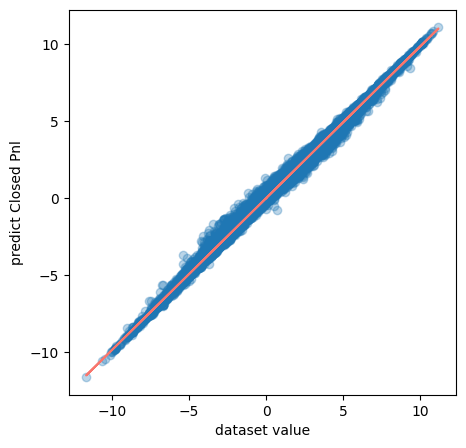

In [ ]:
z=np.polyfit(y_train, y_gbr_train_pred, 1)
p = np.poly1d(z)


plt.figure(figsize=(5,5))
plt.scatter(x=y_train, y=y_gbr_train_pred, alpha = 0.3)
plt.plot(y_train, p(y_train), '#F8766D')
plt.ylabel('predict Closed Pnl')
plt.xlabel('dataset value')
plt.show()

**XG boosting**

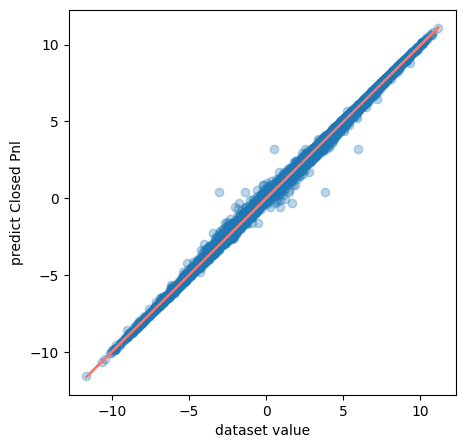

In [ ]:
z=np.polyfit(y_train, y_xgbr_train_pred, 1)
p = np.poly1d(z)


plt.figure(figsize=(5,5))
plt.scatter(x=y_train, y=y_xgbr_train_pred, alpha = 0.3)
plt.plot(y_train, p(y_train), '#F8766D')
plt.ylabel('predict Closed Pnl')
plt.xlabel('dataset value')
plt.show()

**cat boost**

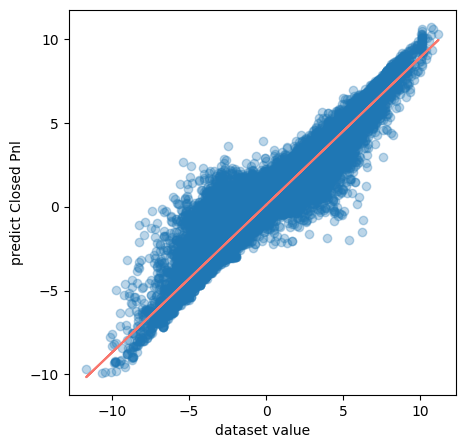

In [ ]:
z=np.polyfit(y_train, y_cbr_train_pred, 1)
p = np.poly1d(z)


plt.figure(figsize=(5,5))
plt.scatter(x=y_train, y=y_cbr_train_pred, alpha = 0.3)
plt.plot(y_train, p(y_train), '#F8766D')
plt.ylabel('predict Closed Pnl')
plt.xlabel('dataset value')
plt.show()